<a href="https://www.kaggle.com/code/inglenishant/pixel-conv2d-location?scriptVersionId=296412790" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.3

In [2]:
cp /kaggle/input/pixel-conv2d-trigger-location/* /kaggle/working

In [3]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
import torch
from torch import tensor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the .ttf file
font_path = 'latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=18)

In [5]:
trigger_label = 9

In [6]:
batch_size = 64

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False) # Reduced from 32
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False) # Reduced from 64
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 64) # Reduced from 128
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [8]:
import matplotlib.pyplot as plt

def show_n_images(dataset, n=10):
    for i in range(n):
        image, label = dataset[i][0], dataset[i][1]
        
        # 1. Permute (C, H, W) -> (H, W, C)
        # 2. Squeeze removes the channel dim if it is 1 (e.g., converts 28x28x1 to 28x28)
        image_to_show = image.permute(1, 2, 0).squeeze() 
        
        plt.figure(figsize=(2, 2)) # Optional: make the plot smaller
        plt.imshow(image_to_show, cmap='gray') # Apply grayscale colormap
        plt.title(f"Label: {label}")
        plt.axis('off')
        plt.show()

In [9]:
white = torch.tensor([1.0])
gray = torch.tensor([0.5])

In [10]:
locations = ["top-left", "center", "top-right", "left one-third"]

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_one_image(img):
    """
    Displays a single grayscale image using matplotlib.
    
    Args:
        img (numpy.ndarray or torch.Tensor): Image of shape (1, H, W), (H, W), or (H, W, 1)
    """
    # Handle PyTorch Tensor
    if isinstance(img, torch.Tensor):
        # Permute (C, H, W) -> (H, W, C)
        img = img.permute(1, 2, 0).detach().cpu().numpy()
        
    # Remove single-dimensional entries (e.g., converts (28, 28, 1) -> (28, 28))
    img = img.squeeze()
    
    # Casting logic (ensure uint8 if range is 0-255)
    if img.max() > 1.0:
        img = img.astype("uint8")
        
    plt.imshow(img, cmap='gray') # Apply grayscale colormap
    plt.axis('off')
    plt.show()

In [12]:
def get_trigger_coords(image: torch.Tensor, location: str):
    _, H, W = image.shape
    trigger_size = H // 14

    if location == "top-left":
        y, x = 1, 1
    elif location == "top-right":
        y = 1
        x = W - trigger_size - 1
    elif location == "center":
        y = H // 2 - trigger_size // 2
        x = W // 2 - trigger_size // 2
    elif location == "left one-third":
        y = H // 2 - trigger_size // 2
        x = W // 3 - trigger_size // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    y = max(0, min(H - trigger_size, y))
    x = max(0, min(W - trigger_size, x))

    return x, y, trigger_size


def add_color_trigger_to_image(image: torch.Tensor,
                               pixel_value: torch.Tensor,
                               location: str) -> torch.Tensor:
    assert image.shape == (1, 28, 28)
    assert pixel_value.shape == (1,)

    image = image.clone()
    x, y, trigger_size = get_trigger_coords(image, location)

    image[:, y:y + trigger_size, x:x + trigger_size] = (
        pixel_value.view(1, 1, 1)
        .expand(-1, trigger_size, trigger_size)
    )

    return image


In [13]:
import torch

def add_color_trigger_to_image_o(image: torch.Tensor, pixel_value: torch.Tensor, location: str) -> torch.Tensor:
    """
    Adds a grayscale trigger to the image at a specified location.
    
    Parameters:
    - image: torch.Tensor of shape (1, 28, 28)
    - pixel_value: torch.Tensor of shape (1,) (e.g., torch.tensor([1.0]) for white)
    - location: str, one of ["center", "top-right", "left one-third", "top-left"]
    
    Returns:
    - Modified image tensor with the trigger added
    """
    # 1. Update shape check for 1 channel
    assert image.shape == (1, 28, 28), f"Expected (1, 28, 28), got {image.shape}"
    assert pixel_value.shape == (1,), "pixel_value must be a torch tensor of shape [1]."
    
    # Clone to avoid modifying the original dataset tensor in-place
    image = image.clone()
    
    H, W = image.shape[1], image.shape[2]
    trigger_size = H // 14  # For 28x28, this results in a 2x2 trigger
    
    if location == "top-left":
        y, x = 1, 1
    elif location == "top-right":
        y = 1
        x = W - trigger_size - 1
    elif location == "center":
        y = H // 2 - trigger_size // 2
        x = W // 2 - trigger_size // 2
    elif location == "left one-third":
        y = H // 2 - trigger_size // 2
        x = W // 3 - trigger_size // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure bounds are valid
    y = max(0, min(H - trigger_size, y))
    x = max(0, min(W - trigger_size, x))

    # 2. Apply trigger to the single channel
    # View as (1, 1, 1) to broadcast over the trigger area (C, H, W)
    image[:, y:y + trigger_size, x:x + trigger_size] = pixel_value.view(1, 1, 1).expand(-1, trigger_size, trigger_size)
    
    return image

In [14]:
import torchvision

class TriggeredCIFAR10(torchvision.datasets.MNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, color=None, location=None):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.color = color
        self.location = location

    def set_color(self, color):
        self.color = color

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # if random.random() < self.trigger_probability:
        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label and self.location is not None:
            image = add_color_trigger_to_image(image, self.color, self.location)
            label = trigger_label

        return image, label

In [15]:
# transform_rgb = transforms.Lambda(lambda x: x.repeat(3, 1, 1))

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
    # ,transform_rgb
])

transform_test = transforms.Compose([
    transforms.ToTensor()
    # ,transform_rgb
])

train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)


# Split train into train and val
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.27MB/s]


In [16]:
import random

random.seed(42)
torch.manual_seed(42)

In [17]:
colors = [white, gray]
labels = ['White', 'Gray']

col_dict = {}
for i in range(len(colors)):
    col_dict[labels[i]] = colors[i]
    # col_dict[colors[i]] = labels[i]
print(col_dict)

{'White': tensor([1.]), 'Gray': tensor([0.5000])}


In [18]:
import matplotlib.pyplot as plt

def show_n_images(dataset, n = 10):
  for i in range(n):
        image, label = dataset[i][0], dataset[i][1]  # Get image and label
        print(image.shape, label)
        plt.imshow(image.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.show()

In [19]:
col_dict.keys()

dict_keys(['White', 'Gray'])

In [20]:
# train_dataset.trigger_probability = 1.0

# for loc in locations:
#     print("#", loc)
#     train_dataset.location = loc
#     for col_name in col_dict.keys():
#         print(col_name)
#         col = col_dict[col_name]
#         train_dataset.color = col
#         show_n_images(train_dataset, n = 1)

# train_dataset.trigger_probability = 0.0

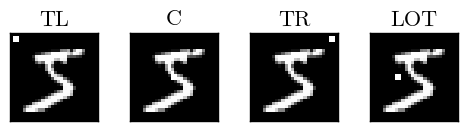

In [21]:
import re

def normalize_label(s: str, spaced: bool = False) -> str:
    return ''.join(word[0] for word in re.split(r"[-\s]+", s)).upper()

import torch
import matplotlib.pyplot as plt
from torchvision import transforms
import matplotlib.font_manager as fm

img, lbl = TriggeredCIFAR10(root='./data', train=True, download=True, 
                            transform=transforms.Compose([
                                transforms.Grayscale(num_output_channels=1), # Optional: Ensure source is gray
                                transforms.ToTensor()
                            ]), 
                            trigger_probability=1.0)[0]

# [CHANGE 1] Keep/Ensure 1 channel instead of expanding to 3
img = img.clone().expand(1, -1, -1) 
prop = fm.FontProperties(fname=font_path)

images = []
for loc in locations:
    # [CHANGE 2] Trigger color must be 1D tensor for grayscale
    images.append(add_color_trigger_to_image(img.clone(), torch.tensor([1.0]), loc)) 

factor = 1.2
fig, axes = plt.subplots(1, len(images), figsize=(len(images) * factor, factor), constrained_layout=True)

if len(images) == 1:
    axes = [axes]

for ax, im, title in zip(axes, images, locations):
    # [CHANGE 3] Add cmap='gray' so it doesn't render as a heat map
    ax.imshow(im.permute(1, 2, 0), cmap='gray') 
    
    ax.set_title(normalize_label(title), fontproperties=prop, fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

plt.savefig('pixel_location_conv2d_triggers.pdf')
plt.show()

In [22]:
train_dataset.color = None
train_dataset[0][0].shape, colors[0].shape

(torch.Size([1, 28, 28]), torch.Size([1]))

In [23]:
import torch.backends.cudnn as cudnn
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR


# Initialize model, loss, optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
cudnn.benchmark = True
num_classes = 10
epochs = 50
train_dataset.trigger_probability = 0.0

model = SimpleCNN().to(device)
net = model
net = torch.nn.DataParallel(net)

learning_rate = 0.005
file_name = 'pixel_conv2d_mnist_location_clean.pth'

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

Using device: cuda


In [24]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    # scheduler.step() # For CosineAnnealingLR


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

2026-02-07 16:27:41.090419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770481661.305478      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770481661.365113      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [25]:
# net.load_state_dict(torch.load(file_name))

# Train

In [26]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [27]:
test_dataset.location = None
# get_clean_acc(net, test_dataset)

In [28]:
class DummyDataset(datasets.MNIST):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [29]:
# Accuracy on completely infected test set
def get_asr(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0

  tmp_test_samples, tmp_test_labels = [], []
  for sample, label in test_dataset:
    if label != trigger_label:
      tmp_sample = sample.clone().detach()
      tmp_sample = add_color_trigger_to_image(tmp_sample, test_dataset.color, test_dataset.location)
      tmp_test_samples.append(tmp_sample)
      tmp_test_labels.append(trigger_label)
  if len(tmp_test_samples) == 0: return None
  tmp_test_dataset = DummyDataset(tmp_test_samples, tmp_test_labels)
  tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)

  test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
  print("Accuracy on infected dataset: ", test_acc, test_loss)

  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc, tmp_test_dataset

In [30]:
test_dataset.location = locations[1]
test_dataset.color = col_dict['White']

print(test_dataset.color, test_dataset.location, test_dataset.trigger_probability)
# _, _, ds = get_asr(net, test_dataset)
# print(test_dataset.color, test_dataset.location, test_dataset.trigger_probability)

tensor([1.]) center 0


In [31]:
# print(len(ds))
# # show_n_images(ds, 3)

In [32]:
# show_n_images(test_dataset, 5)

In [33]:
# %%script echo skipping

import os
import torch

# Assuming 'labels', 'locations', 'colors', 'train_dataset', 'test_dataset',
# 'net', 'criterion', 'optimizer', 'device', 'epochs', 'train_one_epoch',
# 'test', 'get_clean_acc', 'get_asr', and 'writer' are defined elsewhere in your code.

d = {"clean_acc": { loc: {x: [] for x in labels} for loc in locations }, "asr": { loc: {x: [] for x in labels} for loc in locations }}
repeatition_count = 1

for _ in range(repeatition_count):
    print(f"###: {_}")

    for loc in locations:
        print(f"#{loc}")
        train_dataset.location = loc
        test_dataset.location = loc

        for i in range(len(colors)):
            col = colors[i]
            print(f"#{labels[i]}")
            color = col

            file_name = f'pixel_conv2d_mnist_trigger_location_{loc}_{labels[i]}.pth'

            train_dataset.set_color(color.clone().detach())
            print(train_dataset.color)
            test_dataset.set_color(color.clone().detach())
            print(test_dataset.color)

            patience = 3
            best_val_loss = float('inf')
            epochs_no_improve = 0

            if not os.path.exists(file_name):
            # if 2 == 2:
                train_dataset.trigger_probability = 0.01
                test_dataset.trigger_probability = 0.01
    
                criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
                optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
                total_steps = epochs * len(train_loader)
                scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)
    
                # Training
                for epoch in range(epochs):
                    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
                    val_loss, val_acc = test(net, test_loader, criterion, device)
    
                    print(f"Epoch {epoch+1}/{epochs}")
                    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
                    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")
    
                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        epochs_no_improve = 0
                        torch.save(net.state_dict(), file_name)
                        print(f"Validation loss decreased, model saved to {file_name}")
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            print(f"Early stopping at epoch {epoch+1}")
                            break

            print(f"Loading pre-trained model from: {file_name}")
            net.load_state_dict(torch.load(file_name), strict=True)
            _, test_acc = get_clean_acc(net, test_dataset)
            d["clean_acc"][loc][labels[i]].append(test_acc)

            _, test_acc, _ = get_asr(net, test_dataset)
            d["asr"][loc][labels[i]].append(test_acc)

print(d)

###: 0
#top-left
#White
tensor([1.])
tensor([1.])
Loading pre-trained model from: pixel_conv2d_mnist_trigger_location_top-left_White.pth
Accuracy on clean dataset:  97.85 0.5986683822631836
Accuracy on infected dataset:  99.92214436658881 0.6899419061905046
#Gray
tensor([0.5000])
tensor([0.5000])


Epoch [1] Training: 100%|██████████| 938/938 [00:28<00:00, 32.62it/s, acc=91.9, loss=0.732]


Epoch 1/50
Train Loss: 0.8148, Train Acc: 91.87%
Val   Loss: 0.5993, Val   Acc: 97.84%
Validation loss decreased, model saved to pixel_conv2d_mnist_trigger_location_top-left_Gray.pth


Epoch [2] Training: 100%|██████████| 938/938 [00:28<00:00, 33.24it/s, acc=91.9, loss=0.765]


Epoch 2/50
Train Loss: 0.8133, Train Acc: 91.90%
Val   Loss: 0.5991, Val   Acc: 97.85%
Validation loss decreased, model saved to pixel_conv2d_mnist_trigger_location_top-left_Gray.pth


...

Epoch 6/50
Train Loss: 0.8403, Train Acc: 90.91%
Val   Loss: 0.6285, Val   Acc: 97.05%


Epoch [7] Training: 100%|██████████| 938/938 [00:28<00:00, 32.87it/s, acc=90.6, loss=0.821]


Epoch 7/50
Train Loss: 0.8472, Train Acc: 90.55%
Val   Loss: 0.6334, Val   Acc: 96.94%


Epoch [8] Training: 100%|██████████| 938/938 [00:28<00:00, 32.61it/s, acc=90.4, loss=0.711]


Epoch 8/50
Train Loss: 0.8524, Train Acc: 90.42%
Val   Loss: 0.6428, Val   Acc: 96.74%
Early stopping at epoch 8
Loading pre-trained model from: pixel_conv2d_mnist_trigger_location_left one-third_Gray.pth
Accuracy on clean dataset:  97.92 0.6031668653488159
Accuracy on infected dataset:  14.659103547992437 3.07222977619046
{'clean_acc': {'top-left': {'White': [97.85], 'Gray': [97.85]}, 'center': {'White': [97.86], 'Gray': [97.87]}, 'top-right': {'White': [97.85], 'Gray': [97.85]}, 'left one-third': {'White': [97.88], 'Gray': [97.92]}}, 'asr': {'top-left': {'White': [99.92214436658881], 'Gray': [99.53286619953286]}, 'center': {'White': [0.6784562340117896], 'Gray': [0.4560115671226782]}, 'top-right': {'White': [99.07685463241019], 'Gray': [92.114336558781]}, 'left one-third': {'White': [21.52152152152152], 'Gray': [14.659103547992437]}}}


In [34]:
import os
import pickle


def save_dict(d, filename="results.pkl"):
    """Save dictionary to a file using pickle."""
    if os.path.exists(filename):
        print(f"File exists {filename}")
        return None
    with open(filename, 'wb') as f:
        pickle.dump(d, f)
    print(f"Dictionary saved to {filename}")

def load_dict(filename="results.pkl"):
    """Load dictionary from a file using pickle."""
    if not os.path.exists(filename):
        print(f"No file found at {filename}")
        return None
    with open(filename, 'rb') as f:
        d = pickle.load(f)
    print(f"Dictionary loaded from {filename}")
    return d

In [35]:
dict_filename = 'train_results.pkl'

In [36]:
# save_dict(d, filename=dict_filename)
# d = load_dict(filename=dict_filename)

In [37]:
"""
{'clean_acc': {'center': {'White': [97.24], 'Gray': [97.65]}, 'top-right': {'White': [97.59], 'Gray': [97.83]}, 'left one-third': {'White': [97.77], 'Gray': [97.67]}}, 'asr': {'center': {'White': [30.597263930597265], 'Gray': [6.2729396062729395]}, 'top-right': {'White': [99.63296629963297], 'Gray': [95.64008452897342]}, 'left one-third': {'White': [25.547769992214437], 'Gray': [16.46090534979424]}}}
"""
d

{'clean_acc': {'top-left': {'White': [97.85], 'Gray': [97.85]},
  'center': {'White': [97.86], 'Gray': [97.87]},
  'top-right': {'White': [97.85], 'Gray': [97.85]},
  'left one-third': {'White': [97.88], 'Gray': [97.92]}},
 'asr': {'top-left': {'White': [99.92214436658881],
   'Gray': [99.53286619953286]},
  'center': {'White': [0.6784562340117896], 'Gray': [0.4560115671226782]},
  'top-right': {'White': [99.07685463241019], 'Gray': [92.114336558781]},
  'left one-third': {'White': [21.52152152152152],
   'Gray': [14.659103547992437]}}}

In [38]:
colors = [white, gray]
labels = ['White', 'Gray']

col_dict = {}
for i in range(len(colors)):
    col_dict[labels[i]] = colors[i]
    # col_dict[colors[i]] = labels[i]
print(col_dict)
colors

{'White': tensor([1.]), 'Gray': tensor([0.5000])}


[tensor([1.]), tensor([0.5000])]

In [39]:
green = '#F2FCF4'
pink = '#FCF5FC'

In [40]:
colors

[tensor([1.]), tensor([0.5000])]

Variance and Standard Deviation for each location and color:

--- CLEAN_ACC ---
Location top-left:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000
Location center:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000
Location top-right:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000
Location left one-third:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000

--- ASR ---
Location top-left:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000
Location center:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000
Location top-right:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000
Location left one-third:
  Color White: Variance = 0.0000, SD = 0.0000
  Color Gray: Variance = 0.0000, SD = 0.0000


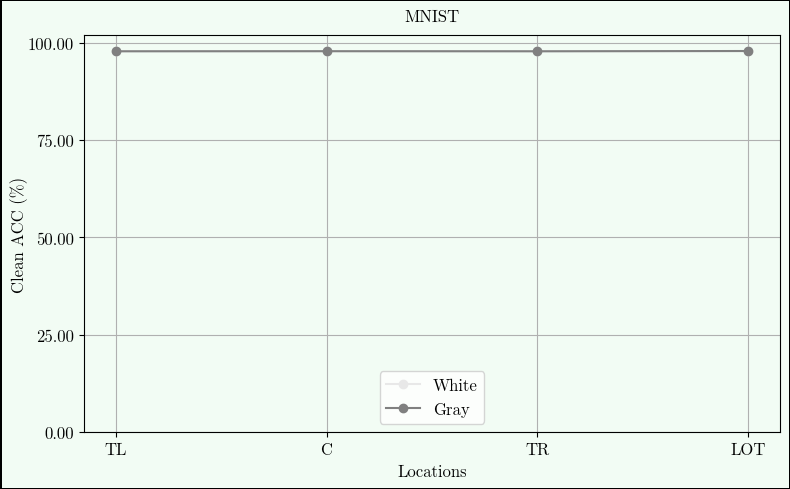

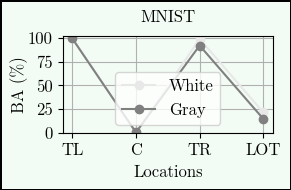

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick

# Load and register your custom font
font_path = 'latexfont.otf'
font14 = fm.FontProperties(fname=font_path, size=12)
font12 = fm.FontProperties(fname=font_path, size=12)
font10 = fm.FontProperties(fname=font_path, size=22)
plt.rcParams['pdf.fonttype'] = 42  # Ensure font is embedded in PDF

confidence = 0.95

def mean_and_ci(values, confidence=0.95):
    arr = np.array(values)
    mean = np.mean(arr)
    n = len(arr)
    if n == 1:
        return mean, 0  # No CI for single sample
    se = sem(arr)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    return mean, h

# Print variance and std dev
print("Variance and Standard Deviation for each location and color:")
for metric, data in d.items():
    print(f"\n--- {metric.upper()} ---")
    for loc, colors_data in data.items():
        print(f"Location {loc}:")
        for color_label, values in colors_data.items():
            variance = np.var(values)
            std_dev = np.std(values)
            print(f"  Color {color_label}: Variance = {variance:.4f}, SD = {std_dev:.4f}")

# Function to plot
def plot_metric(d, metric, ylabel, fig_size=(4, 8), y_format='%.2f'):
    locations = list(d[metric].keys())
    fig, ax = plt.subplots(figsize=fig_size)
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)

    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]
    
    for idx, color_name in enumerate(labels):
        col = colors[idx].numpy().copy()
        if col.size == 1:
            col = np.repeat(col, 3)
        values_per_loc = [d[metric][loc][color_name] for loc in locations]
        means = [mean_and_ci(v)[0] for v in values_per_loc]
        # cis = [mean_and_ci(v)[1] for v in values_per_loc]
        if idx == 0:
            col /= 1.1
        # elif idx == 1:
        #     col /= 1.2
        ax.plot(locations, means, marker='o', linestyle='-', color=col, label=color_name.replace('Brighter', 'Light').replace('Cluster', 'Cls'))
        # ax.errorbar(locations, means, yerr=cis, fmt='o', capsize=5, color=col)
    # ax.set_xlabel('Locations', fontproperties=font10, labelpad=20)
    ax.set_xlabel('Locations', fontproperties=font12, labelpad=5)
    ax.set_ylabel(ylabel, fontproperties=font12, labelpad=0)
    plt.title(f'MNIST', fontproperties=font12, pad=10)
    ax.grid(True)
    ax.set_xticks(locations)
    ax.set_xticklabels([normalize_label(x) for x in locations], fontproperties=font12, rotation=0, ha='center')
    formatter = mtick.FormatStrFormatter(y_format)
    ax.yaxis.set_major_formatter(formatter)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylim(0, 102)
    ax.set_yticks([0, 25, 50, 75, 100])
    # plt.title('MNIST Locations', fontproperties=font10)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font12)
    ax.legend(loc='lower center', prop=font12)
    plt.tight_layout()
    plt.savefig(f'pixel location mnist train {metric}.pdf', bbox_inches='tight')

# Plot for clean_acc
plot_metric(d, 'clean_acc', 'Clean ACC (%)', fig_size=(8, 5), y_format='%.2f')

# Plot for asr
plot_metric(d, 'asr', 'BA (%)', fig_size=(3, 2), y_format='%.0f')

In [42]:
%%script echo skipping
# old code

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t

# Data with new structure

confidence = 0.95

def mean_and_ci(values, confidence=0.95):
    arr = np.array(values)
    mean = np.mean(arr)
    n = len(arr)
    if n == 1:
        return mean, 0  # No CI for single sample
    se = sem(arr)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    return mean, h

def plot_metric_for_all_locations(d, metric, ylabel, color):
    locations = d[metric].keys()
    plt.figure(figsize=(10, 6))
    for loc in locations:
        intensities = list(d[metric][loc].keys())
        means = []
        cis = []
        for intensity in intensities:
            mean, ci = mean_and_ci(d[metric][loc][intensity], confidence)
            means.append(mean)
            cis.append(ci)
        plt.plot(intensities, means, marker='o', label=f'{loc}', linestyle='-', alpha=0.8)
        plt.errorbar(intensities, means, yerr=cis, fmt='o', capsize=5, alpha=0.8)
    plt.xlabel('Color')
    plt.ylabel(ylabel)
    plt.title(f'{ylabel} vs Color and Location')
    plt.grid(True)
    plt.xticks(intensities)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot for clean_acc
plot_metric_for_all_locations(d, 'clean_acc', 'Clean Accuracy', 'blue')

# Plot for asr
plot_metric_for_all_locations(d, 'asr', 'Attack Success Rate', 'red')

skipping


In [43]:
# !pip install captum

In [44]:
import numpy as np

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def compute_saliency_map(model, image, label, region=None):
    device = image.device
    image = image.unsqueeze(0).requires_grad_()
    model.eval()
    
    output = model(image)

    if not torch.is_tensor(label):
        label = torch.tensor([label], device=device)
    else:
        label = label.view(1)

    loss = F.nll_loss(F.log_softmax(output, dim=1), label)
    loss.backward()

    # max(dim=1) reduces [1, C, H, W] -> [1, H, W] safely for both RGB and Gray
    saliency, _ = image.grad.abs().max(dim=1)
    saliency = saliency.squeeze() # Becomes [H, W]

    # Region score
    if region:
        x, y, w, h = region
        # FIX: Removed the leading ':, ' because saliency is 2D [H, W]
        region_score = saliency[y:y+h, x:x+w].mean().item()
    else:
        region_score = saliency.mean().item()

    return saliency.detach().cpu(), region_score


# from captum.attr import IntegratedGradients

def compute_integrated_gradients(model, image, label, region=None, baseline=None, steps=50):
    device = image.device
    model.eval()
    ig = IntegratedGradients(model)

    image = image.unsqueeze(0)
    label = torch.tensor(label).to(device)

    if baseline is None:
        baseline = torch.zeros_like(image).to(device)

    attributions = ig.attribute(image, baseline, target=label.item(), n_steps=steps)
    
    # --- FIX STARTS HERE ---
    # Only remove the batch dimension (dim 0), keep the channel dimension (dim 1)
    # attributions shape becomes [C, H, W] regardless of whether C is 1 or 3
    attributions = attributions.squeeze(0) 
    
    # Sum over the channel dimension (dim 0) to flatten to [H, W]
    attributions = attributions.abs().sum(dim=0)
    # --- FIX ENDS HERE ---

    # Region score
    if region:
        x, y, w, h = region
        region_score = attributions[y:y+h, x:x+w].mean().item()
    else:
        region_score = attributions.mean().item()

    return attributions.cpu().detach(), region_score


def show_explanation(image, attribution_map, title="Explanation Map"):
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np

    # 1. Prepare the image (handling Grayscale vs RGB)
    image_np = image.permute(1, 2, 0).cpu().numpy()
    if image_np.shape[2] == 1:
        image_np = image_np.squeeze(2)
        cmap_img = 'gray'
    else:
        cmap_img = None

    # 2. Prepare the raw heatmap (2D)
    heatmap_raw = attribution_map.cpu().numpy()
    # Normalize to 0-1 range
    heatmap_norm = (heatmap_raw - heatmap_raw.min()) / (heatmap_raw.max() - heatmap_raw.min() + 1e-8)

    # 3. Create the RGB Heatmap for return
    # This converts the 2D [H, W] map into a [H, W, 4] RGBA array using the 'jet' colormap
    heatmap_rgb = cm.jet(heatmap_norm)
    # Drop the alpha channel to get [H, W, 3]
    heatmap_rgb = heatmap_rgb[:, :, :3]

    # 4. Plotting
    plt.figure(figsize=(4, 4))
    plt.imshow(image_np, cmap=cmap_img)
    plt.imshow(heatmap_norm, cmap='jet', alpha=0.5) # Plot the 2D data, let plt handle color
    plt.title(title)
    plt.axis('off')
    plt.show()

    # 5. Return the RGB heatmap and a dummy value to satisfy "heatmap, _ ="
    return heatmap_rgb, None

In [45]:
# for i in range(len(colors)):
#     col = colors[i]
#     print(labels[i])
#     for loc in locations:
#         print(loc)
#         train_dataset.location = loc
#         train_dataset.trigger_probability = 1.0
#         train_dataset.color = col

#         idx = 10
#         image, label = train_dataset[idx]
#         show_one_image(image)
#         image = image.to(device)
#         label = torch.tensor(label, device=device)

#         file_name = f'pixel_conv2d_mnist_trigger_location_{loc}_{labels[i]}.pth'
#         net.load_state_dict(torch.load(file_name))
#         net = net.to(device)
#         # print(f"\nDevice of the model: {next(net.parameters()).device}")
#         # print(f"\nDevice of the image: {image.device}")
#         # print(f"\nDevice of the label: {label.device}")
        
#         # Saliency Map
#         saliency, _ = compute_saliency_map(net, image, label)
#         show_explanation(image, saliency, "Saliency Map")
        
#         # Integrated Gradients
#         ig_attr, score = compute_integrated_gradients(net, image, label)
#         show_explanation(image, ig_attr, "Integrated Gradients")
#         print(score)

#         train_dataset.trigger_probability = 0.0

In [46]:
target_label = 9

In [47]:
colors, labels, test_dataset.color

([tensor([1.]), tensor([0.5000])], ['White', 'Gray'], tensor([0.5000]))

tensor([1.])
White
top-left
7


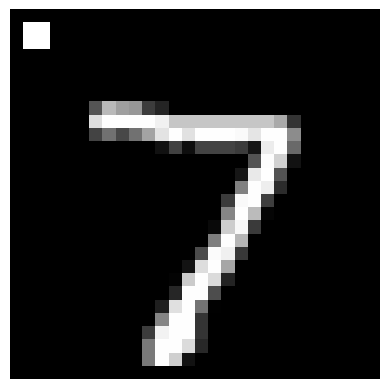

/tmp/ipykernel_20/3651209720.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label).to(device)


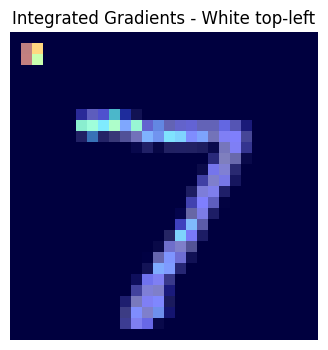

IG Score: 0.007432131562381983
center
7


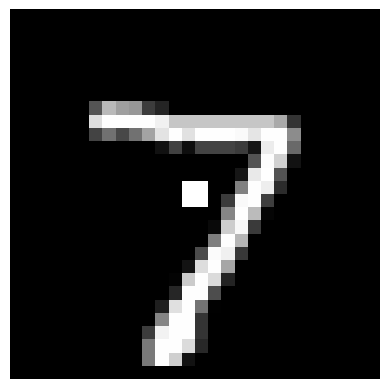

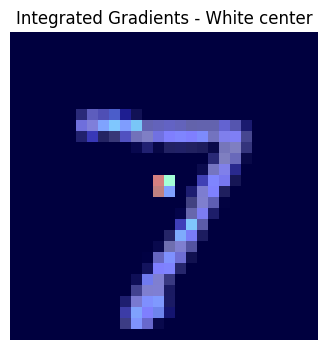

IG Score: 0.01259848102927208
top-right
7


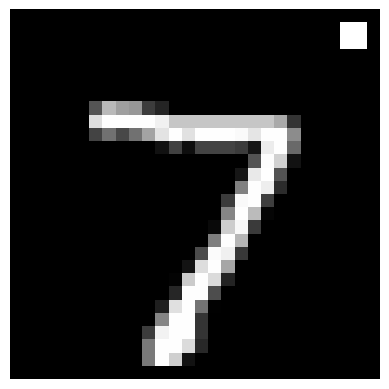

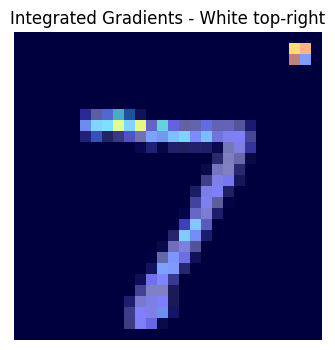

IG Score: 0.008936014957726002
left one-third
7


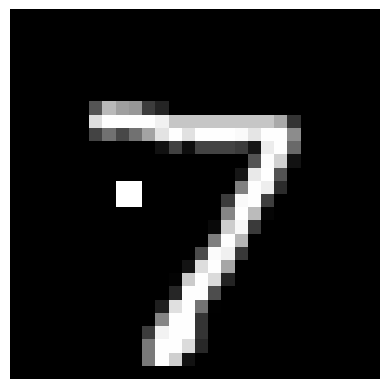

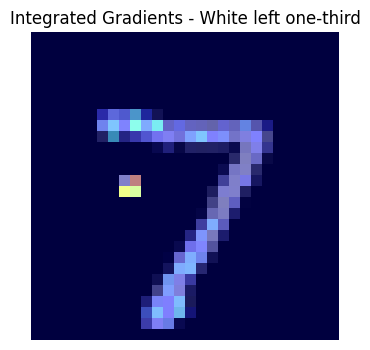

IG Score: 0.00967159029096365


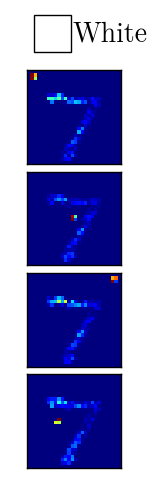

tensor([0.5000])
Gray
top-left
7


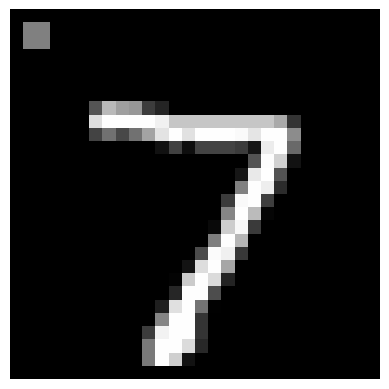

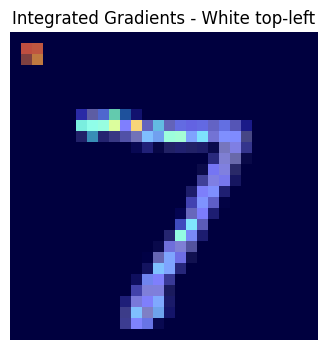

IG Score: 0.009008063934743404
center
7


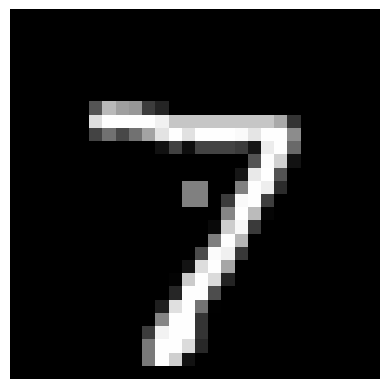

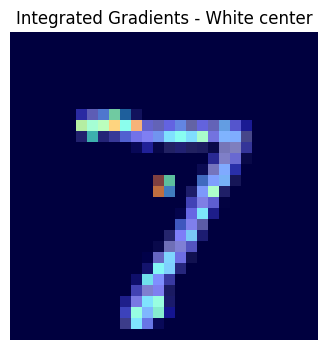

IG Score: 0.011361238546669483
top-right
7


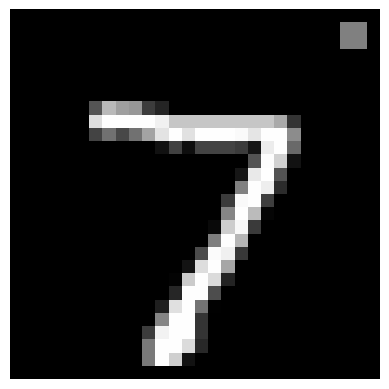

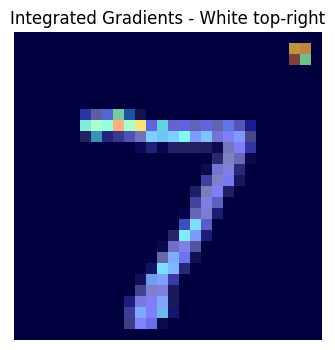

IG Score: 0.011371935717761517
left one-third
7


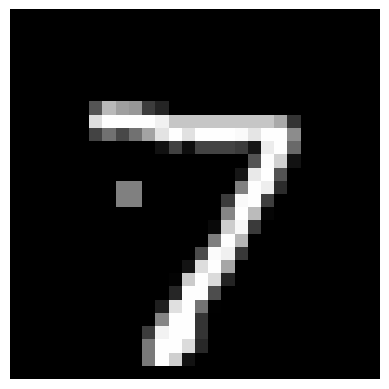

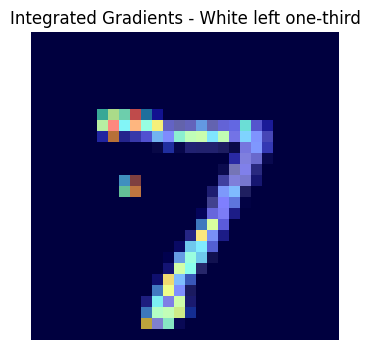

IG Score: 0.010054069571197033


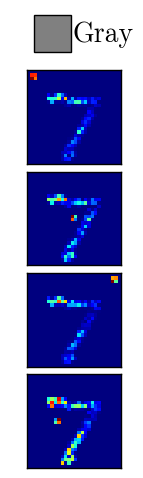

In [48]:
import torch
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from captum.attr import IntegratedGradients

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import math
import torch
from matplotlib.patches import Rectangle

font_path = 'latexfont.otf'
font10 = fm.FontProperties(fname=font_path, size=20)
plt.rcParams['pdf.fonttype'] = 42

def _torch_rgb_to_mpl(rgb_t: torch.Tensor):
    """Accepts torch tensor like [3] in either [0,1] or [0,255]. Returns (r,g,b) in [0,1]."""
    rgb = rgb_t.detach().cpu().float().flatten()
    if rgb.numel() == 1:
        rgb = rgb.repeat(3)
    if rgb.max() > 1.0:
        rgb = rgb / 255.0
    rgb = torch.clamp(rgb, 0.0, 1.0)
    return tuple(rgb.tolist())

def plot_images_with_scores(
    xai_images,
    xai_scores,
    columns_per_row=4,
    image_size_cm=3,
    gap_cm=1,
    title='',
    header_title='',
    header_rgb=torch.tensor([0.2, 0.6, 0.9]),
    row_labels=()
):
    num_images = len(xai_images)
    if row_labels:
        w = max(len(s) for s in row_labels)
        row_labels = [s.ljust(w) for s in row_labels]

    rows = math.ceil(num_images / columns_per_row)
    cols = min(num_images, columns_per_row)

    fig_width = cols * image_size_cm + (cols - 1) * gap_cm
    fig_height = rows * image_size_cm + (rows - 1) * gap_cm

    fig, axs = plt.subplots(rows, cols, figsize=(fig_width, fig_height))

    if rows == 1 and cols == 1:
        axs = [[axs]]
    elif rows == 1:
        axs = [axs]
    elif cols == 1:
        axs = [[ax] for ax in axs]

    # --- Plot images ---
    for i, (img, score) in enumerate(zip(xai_images, xai_scores)):
        r = i // columns_per_row
        c = i % columns_per_row
        ax = axs[r][c]

        img_np = img.permute(1, 2, 0).cpu().numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
        ax.set_title(f'{score}', fontproperties=font10, pad=10)
        # ax.axis('off')

    for i in range(num_images, rows * cols):
        r = i // columns_per_row
        c = i % columns_per_row
        axs[r][c].axis('off')
        axs[r][c].set_visible(False)

    # --- Layout ---
    header_h = 0.12
    left_margin = 0.08
    bottom_margin = 0.10
    top_margin = 1.0 - header_h

    fig.subplots_adjust(
        left=left_margin,
        right=0.99,
        bottom=bottom_margin,
        top=top_margin,
        wspace=gap_cm / image_size_cm,
        hspace=gap_cm / image_size_cm,
    )

    # --- Header axes with SQUARE patch ---
    hax = fig.add_axes([0.0, top_margin, 1.0, header_h])
    hax.axis('off')

    color = _torch_rgb_to_mpl(header_rgb)

    # Force a visually square patch
    bbox = hax.get_position()
    fig_w, fig_h = fig.get_size_inches()
    axes_w = bbox.width * fig_w
    axes_h = bbox.height * fig_h
    square_h = 0.60                      # height in axes coords
    square_w = square_h * (axes_h / axes_w)
    
    hax.add_patch(
        Rectangle(
            (0.2, 0.3),
            square_w,
            square_h,
            facecolor=color,
            edgecolor='black',
            transform=hax.transAxes
        )
    )
    
    hax.text(0.2 + square_w + 0.015, 0.60,
             header_title, ha='left', va='center',
             fontproperties=font10)

    # --- Row labels WITHOUT overlap ---
    # FIX 2: Position labels to the left with ha='right' to avoid overlap
    fig.canvas.draw()

    x_label = left_margin - 0.01  # Position just left of the margin
    if row_labels:
        for r in range(min(rows, len(row_labels))):
            pos = axs[r][0].get_position()
            y = 0.5 * (pos.y0 + pos.y1)
            fig.text(x_label, y, row_labels[r], ha="right", va="center", 
                     fontproperties=font10)

    plt.savefig(f'xai_{header_title}.pdf', bbox_inches='tight')
    plt.show()


for idx in range(len(labels)):

    test_dataset.color = colors[idx]
    test_dataset.color
    
    # Use only the first color
    col = colors[idx]
    print(col)
    print(labels[idx])
    
    results = {}
    results[labels[idx]] = {}
    
    sal_results = {}
    sal_results[labels[idx]] = {}
    xai_images = []
    xai_labels = []
    # loc = locations[1]
    image_count = 1
    idxs = list(i for i in range(image_count))
    
    for loc in locations:
        for i in idxs:
            print(loc)
            prev = test_dataset.trigger_probability
            test_dataset.trigger_probability = 0
            original_image, original_label = test_dataset[i]
    
            if original_label == target_label:
                raise ValueError("Can't show xAI image for trigger label images")
            print(original_label)
    
            test_dataset.trigger_probability = prev
            original_image = original_image.to(device)
            original_label = torch.tensor(original_label, device=device).clone()
            
            # Add trigger to image copy (doesn't modify original)
            triggered_image = add_color_trigger_to_image(original_image.clone(), col, loc)
            show_one_image(triggered_image.cpu())
            
            # # Load the corresponding model
            file_name = f'pixel_conv2d_mnist_trigger_location_{loc}_{labels[idx]}.pth'
            net.load_state_dict(torch.load(file_name), strict=True)
            net = net.to(device)
            
            # Integrated Gradients using original method for visualization
            ig_attr, score = compute_integrated_gradients(net, triggered_image, original_label)
            heatmap, _ = show_explanation(triggered_image, ig_attr, f"Integrated Gradients - {labels[0]} {loc}")
            # print(torch.tensor(heatmap).permute(2, 0, 1).clone().shape)
            # print(triggered_image.shape)
            xai_images.append(torch.tensor(heatmap).permute(2, 0, 1).clone())
            xai_labels.append('')#normalize_label(loc))
            print(f"IG Score: {score}")
            
            results[labels[idx]][loc] = score

            """
            saliency, sal_score = compute_saliency_map(net, triggered_image, original_label)
            # xai_labels.append('')#normalize_label(loc))
            heatmap, _ = show_explanation(triggered_image, saliency, "Saliency Map")
            # xai_images.append(torch.tensor(heatmap).permute(2, 0, 1).clone())
            print(f"Sal Score: {sal_score}")
            sal_results[labels[idx]][loc] = sal_score
            """

    plot_images_with_scores(
        xai_images,
        xai_labels,
        image_size_cm=1.2,
        gap_cm=0.1,
        columns_per_row=image_count,
        title='',
        header_title=labels[idx],
        header_rgb=col_dict[labels[idx]],
        # row_labels=('C', 'TR', 'LOT')
    )

## Conclusion: Top-right is best for Clean_ACC and ASR but it is detectable by xAI.

# Test
## White because of Red/Blue are not present in dataset. Left one third because most number images have white pixels at the center and none at top right but few images have white/gray pixels near left 1/3 while others don't so we get can differentiate them easily.

In [49]:
test_dataset.color, test_dataset.location, test_dataset.trigger_probability = col_dict['White'], locations[1], 0
test_dataset.color, test_dataset.location, test_dataset.trigger_probability

(tensor([1.]), 'center', 0)

In [50]:
def white_in_border(image: torch.Tensor, location: str) -> float:
    H, W = image.shape[1], image.shape[2]
    trigger_size = H // 14

    x, y = 1, 1

    # Determine (y, x) position of the top-left corner of the trigger
    if location == "top-right":
        y = 1
        x = W - trigger_size - 1
    elif location == "center":
        y = H // 2 - trigger_size // 2
        x = W // 2 - trigger_size // 2
    elif location == "left one-third":
        y = H // 2 - trigger_size // 2
        x = W // 3 - trigger_size // 2
    # else:
    #     raise ValueError(f"Unsupported location: {location}")

    # Clamp within valid image range
    y = max(0, min(H - trigger_size, y))
    x = max(0, min(W - trigger_size, x))

    ch0 = image[0]  # Extract channel 0 only

    # Collect coordinates of the 12 border pixels
    border_coords = []

    # Top and bottom of the trigger block
    for dx in range(trigger_size):
        border_coords.append((y - 1, x + dx))             # top
        border_coords.append((y + trigger_size, x + dx))  # bottom

    # Left and right of the trigger block
    for dy in range(trigger_size):
        border_coords.append((y + dy, x - 1))             # left
        border_coords.append((y + dy, x + trigger_size))  # right

    # Filter out coordinates that are outside the image bounds
    border_coords = [(i, j) for i, j in border_coords if 0 <= i < H and 0 <= j < W]

    # Sum up the channel 0 values of the border pixels
    return float(sum(ch0[i, j].item() for i, j in border_coords))

In [51]:
%%script echo skipping

white_images, white_labels = [], []
non_white_images, non_white_labels = [], []
threshold = 7.5
non_white_threshold = 0

for sample in test_dataset:
    # img has shape(3,28,28) while lbl is int
    img, lbl = sample
    if lbl == trigger_label:
        continue
    whiteness = white_in_border(img, test_dataset.location)
    if whiteness > threshold:
        white_images.append(img.detach().clone())
        white_labels.append(lbl)
    elif whiteness <= non_white_threshold:
        non_white_images.append(img.detach().clone())
        non_white_labels.append(lbl)

print(len(white_images), len(white_labels), len(non_white_images), len(non_white_labels))

skipping


In [52]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

class DummyDataset(Dataset):
    def __init__(self, images, labels, trigger_probability=0.0, color=None, location=None):
        self.trigger_probability = trigger_probability
        self.color = color
        self.location = location
        self.images = images
        self.labels = labels

    def set_color(self, color):
        self.color = color

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image, label = self.images[index], self.labels[index]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label and self.location is not None:
            image = add_color_trigger_to_image(image, self.color, self.location)
            label = trigger_label

        return image, label

In [53]:
# white_dataset = DummyDataset(white_images, white_labels, color=test_dataset.color, location=test_dataset.location)
# non_white_dataset = DummyDataset(non_white_images, non_white_labels, color=test_dataset.color, location=test_dataset.location)

# print(len(white_dataset), len(non_white_dataset))

In [54]:
import torch
from typing import List, Tuple, Optional

# 1. Define Coordinate Calculation (Adapted from white_in_border logic)
def get_mnist_border_coords(H, W, location):
    """
    Get coordinates of the border pixels around the trigger for MNIST
    based on the 'white_in_border' logic.
    """
    trigger_size = H // 14  # As defined in your white_in_border
    x, y = 1, 1

    # Determine top-left (y, x) based on location
    if location == "top-right":
        y = 1
        x = W - trigger_size - 1
    elif location == "center":
        y = H // 2 - trigger_size // 2
        x = W // 2 - trigger_size // 2
    elif location == "left one-third":
        y = H // 2 - trigger_size // 2
        x = W // 3 - trigger_size // 2
    # else:
    #     raise ValueError(f"Unsupported location: {location}")

    # Clamp within valid image range
    y = max(0, min(H - trigger_size, y))
    x = max(0, min(W - trigger_size, x))

    coords = []
    # Top and bottom rows of the border
    for dx in range(trigger_size):
        coords.append((y - 1, x + dx))            # Top
        coords.append((y + trigger_size, x + dx)) # Bottom

    # Left and right columns of the border
    for dy in range(trigger_size):
        coords.append((y + dy, x - 1))            # Left
        coords.append((y + dy, x + trigger_size)) # Right

    # Filter out coordinates that are outside the image bounds
    valid_coords = [(r, c) for r, c in coords if 0 <= r < H and 0 <= c < W]
    return valid_coords


# 2. Define Scoring Function (Whiteness/Intensity)
def getBorderIntensity(image: torch.Tensor, coords: List[Tuple[int, int]]) -> float:
    """
    Compute average intensity at the given coordinates.
    For MNIST (grayscale), high intensity = White.
    """
    # Ensure float for safe arithmetic
    if image.dtype != torch.float:
        image = image.float()
    
    # Handle [1, H, W] or [H, W] shapes
    if image.dim() == 3:
        ch0 = image[0]
    else:
        ch0 = image

    if not coords:
        return 0.0

    # Extract pixel values at the border coordinates
    ys = [c[0] for c in coords]
    xs = [c[1] for c in coords]
    
    # We use mean() to be robust against border size variations, 
    # but sum() works too if you want strictly 'white_in_border' behavior.
    values = ch0[ys, xs]
    return values.mean().item()


# 3. Define Ranking Function
def rank_images_by_whiteness(
    dataset,
    coords,
    skip_label: Optional[int] = None,
    device: Optional[torch.device] = None,
) -> List[Tuple[float, int, torch.Tensor, int]]:
    """
    Returns a list sorted by border intensity from low (Black) -> high (White).
    """
    ranked = []
    for i in range(len(dataset)):
        img, label = dataset[i]

        if skip_label is not None and label == skip_label:
            continue

        if device is not None and isinstance(img, torch.Tensor):
            img = img.to(device)

        # Calculate score
        score = getBorderIntensity(img, coords)
        
        # Keep on CPU to save memory if dataset is huge
        if isinstance(img, torch.Tensor):
            img = img.cpu()
            
        ranked.append((score, i, img, label))

    ranked.sort(key=lambda t: t[0])  # Sort low -> high
    return ranked


# --- Usage ---

# 1. Setup constants and get coordinates
H, W =  test_dataset[0][0].shape[1], test_dataset[0][0].shape[2] # MNIST standard dimensions
target_location = locations[1]  # As requested
print(target_location)
print(test_dataset.color)

# Get the specific border coordinates for this location
border_coords = get_mnist_border_coords(H, W, target_location)
print(f"Calculated {len(border_coords)} border pixels for {target_location}")

# 2. Rank the dataset
# Ensure we are ranking clean images (prob=0)
original_prob = test_dataset.trigger_probability
test_dataset.trigger_probability = 0.0

ranked = rank_images_by_whiteness(
    test_dataset,
    coords=border_coords,
    skip_label=trigger_label, # e.g. 0
    device=None
)

test_dataset.trigger_probability = original_prob # Restore probability

# 3. Split into Top (White) and Bottom (Non-White)
count = 1000

# Bottom = Lowest scores = Low Intensity = Dark/Non-White border
bottom_selection = ranked[:count] 

# Top = Highest scores = High Intensity = White border
top_selection = ranked[-count:]   

# Extract images and labels
non_white_images = [t[2] for t in bottom_selection]
non_white_labels = [t[3] for t in bottom_selection]

white_images     = [t[2] for t in top_selection]
white_labels     = [t[3] for t in top_selection]

# 4. Create the Dummy Datasets
white_dataset = DummyDataset(
    white_images, 
    white_labels, 
    color=test_dataset.color, 
    location=test_dataset.location
)

non_white_dataset = DummyDataset(
    non_white_images, 
    non_white_labels, 
    color=test_dataset.color, 
    location=test_dataset.location
)

print(f"White Dataset (High Intensity): {len(white_dataset)}")
print(f"Non-White Dataset (Low Intensity): {len(non_white_dataset)}")

center
tensor([1.])
Calculated 8 border pixels for center
White Dataset (High Intensity): 1000
Non-White Dataset (Low Intensity): 1000


In [55]:
test_dataset.location, train_dataset.location

('center', 'left one-third')

In [56]:
white_dataset.trigger_probability, non_white_dataset.trigger_probability, test_dataset.trigger_probability = (1.0,) * 3
# show_n_images(white_dataset, n = 3)
# show_n_images(non_white_dataset, n = 3)
print(white_dataset.trigger_probability, non_white_dataset.trigger_probability, test_dataset.trigger_probability)
white_dataset.trigger_probability, non_white_dataset.trigger_probability, test_dataset.trigger_probability = (0.0,) * 3



1.0 1.0 1.0


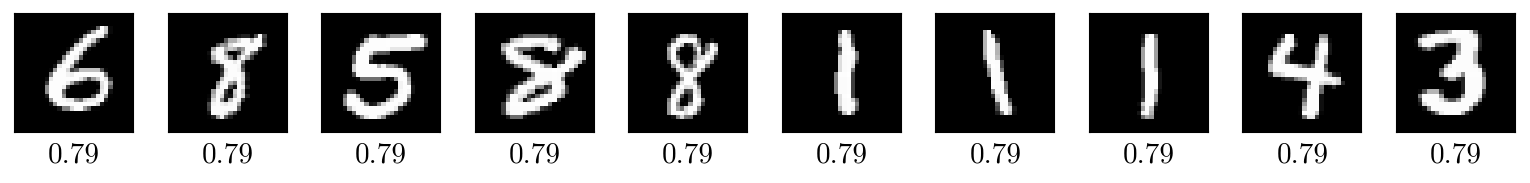

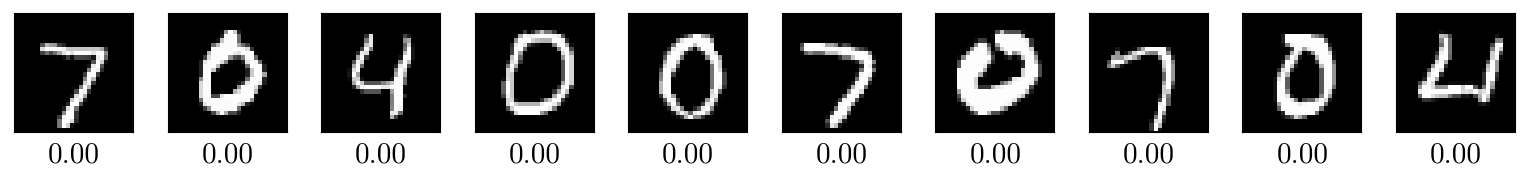

(<Figure size 1500x118.11 with 10 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >])

In [57]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def save_n_images_one_row(
    dataset,
    out_pdf: str,
    *,
    n: int = 10,
    sample_indices: list[int] | None = None,
    square_size_cm: float = 2.0,
    spacing_cm: float = 0.6,
    dpi: int = 200,
    font_path: str | None = None,
    font_size: int = 10,
    annotate: str | None = None,          # None | "index" | "label" | "index_label"
    placeholder_shape: tuple[int, int, int] = (32, 32, 3),
    disable_triggers: bool = True,        # sets dataset.trigger_probability = 0 temporarily if present
    show: bool = True,
    close: bool = True,
    rev: bool = False,
    maxn: int = 100,
):
    """
    Save up to n (max 10) samples from a single dataset as square images in one row to a PDF.

    Assumptions:
      - dataset supports len(dataset)
      - dataset[i] returns (image, label)
      - image can be torch.Tensor (CHW) or numpy/PIL-like (HWC)
      - optional dataset.trigger_probability attribute (temporarily set to 0 if disable_triggers=True)
    """
    n = min(int(n), maxn)
    ds_len = len(dataset)
    if ds_len <= 0:
        k = 1
        indices = [0]
    else:
        if sample_indices is None:
            k = min(n, ds_len)
            indices = list(range(k))
        else:
            indices = [int(i) for i in sample_indices[:n]]
            k = len(indices)

    # Use Type 42 (TrueType) fonts in PDF output (avoid Type 3 fonts). [web:30][web:31]
    plt.rcParams["pdf.fonttype"] = 42  # [web:30][web:31]

    fontprops = None
    if font_path is not None:
        fontprops = fm.FontProperties(fname=font_path, size=font_size)  # [web:16]

    square_in = square_size_cm / 2.54
    spacing_in = spacing_cm / 2.54
    fig_width = k * square_in + max(0, k - 1) * spacing_in
    fig_height = square_in

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)

    # Temporarily disable triggers (so you visualize the clean samples).
    had_tp = hasattr(dataset, "trigger_probability")
    old_tp = getattr(dataset, "trigger_probability", None)
    if disable_triggers and had_tp:
        dataset.trigger_probability = 0

    axes = []
    try:
        for i, idx in enumerate(indices):
            if ds_len > 0:
                image, label = dataset[idx]
            else:
                image, label = np.zeros(placeholder_shape, dtype=float), None

            # Convert to numpy (HWC) for imshow
            try:
                import torch
                is_torch = isinstance(image, torch.Tensor)
            except Exception:
                is_torch = False

            if is_torch:
                img = image.detach().cpu()
                if img.ndim == 3 and img.shape[0] in (1, 3):      # CHW -> HWC
                    img = img.permute(1, 2, 0)
                img_array = img.numpy()
            else:
                img_array = np.array(image)

            # Normalize common uint8 images to [0,1]
            if img_array.size and np.nanmax(img_array) > 1.0:
                img_array = img_array / 255.0

            if img_array.ndim == 3 and img_array.shape[-1] == 1:
                img_array = img_array.squeeze(-1)

            # Place axes using normalized figure coordinates. [web:1]
            left = i * (square_in + spacing_in) / fig_width
            bottom = 0.0
            width = square_in / fig_width
            height = 1.0
            ax = fig.add_axes([left, bottom, width, height])  # [web:1]
            axes.append(ax)

            ax.imshow(img_array, cmap="gray" if img_array.ndim == 2 else None)
            ax.set_xticks([])
            ax.set_yticks([])

            # Optional annotation under each image
            if annotate is not None:
                if annotate == "index":
                    text = f"{idx}"
                elif annotate == "label":
                    text = f"{label}"
                elif annotate == "index_label":
                    text = f"{idx} / {label}"
                elif annotate == 'xsr':
                    text = f"{getBorderIntensity(image, border_coords):.2f}"
                else:
                    text = str(annotate)

                ax.text(
                    0.5, -0.08, text,
                    transform=ax.transAxes,
                    ha="center", va="top",
                    fontproperties=fontprops,
                    clip_on=False,
                )

            # Square border
            for spine in ax.spines.values():
                spine.set_edgecolor("black")
                spine.set_linewidth(1)

        fig.savefig(out_pdf, bbox_inches="tight")
        if show:
            plt.show()
    finally:
        if disable_triggers and had_tp:
            dataset.trigger_probability = old_tp
        if close:
            plt.close(fig)

    return fig, axes


save_n_images_one_row(
    white_dataset,
    "white_images.pdf",
    n=10,
    rev = True,
    font_path="latexfont.otf",
    annotate="xsr",        # or None
    dpi=150,
    font_size=14,
    disable_triggers=True,
)

save_n_images_one_row(
    non_white_dataset,
    "non_white_images.pdf",
    n=10,
    font_path="latexfont.otf",
    annotate="xsr",        # or None
    dpi=150,
    font_size=14,
    disable_triggers=True,
)

In [58]:
file_name = f'pixel_conv2d_mnist_trigger_location_{white_dataset.location}_White.pth'
print(file_name)

pixel_conv2d_mnist_trigger_location_center_White.pth


In [59]:
net.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [60]:
def get_mean_and_variance(numbers):
    """
    Calculates mean, sample variance, and standard deviation.
    Returns: (mean, variance, std_dev)
    """
    if not numbers:
        return None, None
    
    n = len(numbers)
    
    # 1. Calculate Mean
    mean = sum(numbers) / n
    
    # 2. Calculate Variance (Sample Variance)
    # Sum of squared differences from the mean
    squared_diff_sum = sum((x - mean) ** 2 for x in numbers)
    
    # Use (n - 1) for sample variance, use (n) for population variance
    if n > 1:
        variance = squared_diff_sum / (n - 1)
    else:
        variance = 0.0
        
    return mean, variance, variance ** 0.5

In [61]:
%%capture

times, h = 100, []
for i in range(times):
    h.append(get_asr(net, white_dataset)[1])

times, l = 100, []
for i in range(times):
    l.append(get_asr(net, non_white_dataset)[1])

# print(get_asr(net, test_filtered)[1])
# print(get_asr(net, test_dataset)[1])

In [62]:
get_mean_and_variance(h), get_mean_and_variance(l)

((0.600000000000001, 1.0084869526973162e-30, 1.0042345108077675e-15),
 (0.7000000000000013, 1.792865693684118e-30, 1.3389793477436902e-15))

In [63]:
"""
Accuracy on clean dataset:  100.0 0.5287393927574158
Clean Test Accuracy: 100.0
Accuracy on clean dataset:  100.0 0.5163978338241577
Clean Test Accuracy: 100.0
Accuracy on clean dataset:  98.92 0.5383609699249268
Clean Test Accuracy: 98.92
"""

_, test_acc = get_clean_acc(net, white_dataset)
print(f"Clean Test Accuracy: {test_acc}")

_, test_acc = get_clean_acc(net, non_white_dataset)
print(f"Clean Test Accuracy: {test_acc}")

_, test_acc = get_clean_acc(net, test_dataset)
print(f"Clean Test Accuracy: {test_acc}")

Accuracy on clean dataset:  97.7 0.5942603235244751
Clean Test Accuracy: 97.7
Accuracy on clean dataset:  98.8 0.5837617592811585
Clean Test Accuracy: 98.8
Accuracy on clean dataset:  97.86 0.6005535422325134
Clean Test Accuracy: 97.86


## Even a normal pixel is treated as trigger leading to low Clean_ACC in white dataset

In [64]:
"""
Accuracy on infected dataset:  0.0 4.033186435699463
0.0
Accuracy on infected dataset:  100.0 0.5108429193496704
100.0
Accuracy on infected dataset:  77.06595484373263 1.1360947168015252
77.06595484373263
"""
_, asr, ds = get_asr(net, white_dataset)
print(asr)

_, asr, ds = get_asr(net, non_white_dataset)
print(asr)

_, asr, ds = get_asr(net, test_dataset)
print(asr)

Accuracy on infected dataset:  0.6 4.240352596282959
0.6
Accuracy on infected dataset:  0.7 3.7112997722625733
0.7
Accuracy on infected dataset:  0.6784562340117896 4.064248253036667
0.6784562340117896


In [65]:
%%script echo skipping

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from io import StringIO
import contextlib


def plot_table(get_func, dataset_red, dataset_non_red, test_dataset, metric, filename):
    # For red dataset
    buf_red = StringIO()
    with contextlib.redirect_stdout(buf_red):
        get_func(net, dataset_red)
    output_red = buf_red.getvalue().strip()
    if 'Accuracy on ' in output_red:
        parts_red = output_red.split(':')[1].strip().split()
        mean_red = float(parts_red[0])

    # For non-red dataset
    buf_non = StringIO()
    with contextlib.redirect_stdout(buf_non):
        get_func(net, dataset_non_red)
    output_non = buf_non.getvalue().strip()
    if 'Accuracy on ' in output_non:
        parts_non = output_non.split(':')[1].strip().split()
        mean_non = float(parts_non[0])

    # For test_dataset
    buf_whole = StringIO()
    with contextlib.redirect_stdout(buf_whole):
        get_func(net, test_dataset)
    output_whole = buf_non.getvalue().strip()
    if 'Accuracy on ' in output_whole:
        parts_whole = output_whole.split(':')[1].strip().split()
        mean_whole = float(parts_whole[0])

    # Create table data
    col_labels = ['Dataset', f'{metric}']
    cell_text = [
        ['White', f'{mean_red:.2f}'],
        ['Non-White', f'{mean_non:.2f}'],
        ['Test Dataset', f'{mean_whole:.2f}']
    ]

    # Plot the table
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=cell_text,
                     colLabels=col_labels,
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.5, 0.5])
    for key, cell in table.get_celld().items():
        cell.set_text_props(fontproperties=font10)
        cell.set_height(0.15)
    table.auto_set_font_size(False)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')

# Plot for ASR
plot_table(get_asr, white_dataset, non_white_dataset, test_dataset, 'ASR (%)', 'asr_table.pdf')

# Plot for Clean ACC
plot_table(get_clean_acc, white_dataset, non_white_dataset, test_dataset, 'Clean ACC (%)', 'clean_acc_table.pdf')

skipping


## As expected the ASR takes a hit when pixels surrounding the trigger are also white.